In [1]:
import scanpy as sc
import pandas as pd
import os

# 디렉토리 설정
data_dir = "/home/Data_Drive_8TB/kykim/colon/Macrophage/"
adatas = []
# 파일 리스트와 sample 이름 정의
files = {
    "Mac_0hrs": "GSM5012287_Mac_0hrs_scRNAseq_counts.csv.gz",
    "M1_3hrs": "GSM5012288_M1_3hrs_scRNAseq_counts.csv.gz",
    "M1_6hrs": "GSM5012289_M1_6hrs_scRNAseq_counts.csv.gz",
    "M1_12hrs": "GSM5012290_M1_12hrs_scRNAseq_counts.csv.gz",
    "M1_24hrs": "GSM5012291_M1_24hrs_scRNAseq_counts.csv.gz",
    "M2_3hrs": "GSM5012292_M2_3hrs_scRNAseq_counts.csv.gz",
    "M2_6hrs": "GSM5012293_M2_6hrs_scRNAseq_counts.csv.gz",
    "M2_12hrs": "GSM5012294_M2_12hrs_scRNAseq_counts.csv.gz",
    "M2_24hrs": "GSM5012295_M2_24hrs_scRNAseq_counts.csv.gz"}

for sample_name, filename in files.items():
    file_path = os.path.join(data_dir, filename)
    
    # CSV 파일을 pandas DataFrame으로 불러오기 (index_col=0 은 gene명 기준)
    df = pd.read_csv(file_path, index_col=0)
    
    # DataFrame을 AnnData로 변환
    adata = sc.AnnData(df.transpose())  # cells x genes 형태로 transpose 필요
    adata.obs['sample'] = sample_name
    
    # Cell 이름 prefix로 구분 가능하도록 바꾸기
    adata.obs_names = [f"{sample_name}_{cell}" for cell in adata.obs_names]
    
    adatas.append(adata)

# 병합
adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감
def assign_cell_type(sample):
    if sample.startswith("Mac_"):
        return "M0"
    elif sample.startswith("M1_"):
        return "M1"
    elif sample.startswith("M2_"):
        return "M2"
    else:
        return "Unknown"

adata.obs['cell_type'] = adata.obs['sample'].apply(assign_cell_type)
adata.obs['type'] = 'train_data'
print(adata.obs['cell_type'].value_counts())


/tmp/ipykernel_744434/3431913049.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감


cell_type
M0    4145
M1    1904
M2    1527
Name: count, dtype: int64


In [2]:
import scanpy as sc

# h5ad 파일 경로
file_path = '/home/Data_Drive_8TB/kykim/GC/Macrophage.h5ad'

# h5ad 파일 읽기
trainadata = sc.read_h5ad(file_path)
import pandas as pd
import numpy as np
import scipy.sparse as sp

# obs, var를 빈 DataFrame으로 초기화
trainadata.obs = pd.DataFrame(index=trainadata.obs_names)
trainadata.var = pd.DataFrame(index=trainadata.var_names)

# uns를 빈 딕셔너리로 초기화
trainadata.uns = {}

# obsm, varm을 빈 dict로 초기화
trainadata.obsm = {}
trainadata.varm = {}

# layers를 빈 dict로 초기화
trainadata.layers = {}

# obsp를 빈 dict로 초기화
trainadata.obsp = {}
trainadata.obs['type'] = 'predict_data'
trainadata.obs['cell_type'] = 'predict_data'
trainadata.obs['sample'] = 'predict_data'

In [3]:
trainadata

AnnData object with n_obs × n_vars = 13967 × 25750
    obs: 'type', 'cell_type', 'sample'

In [4]:
import anndata as ad

# outer join으로 concat (관측값 방향으로 합치기: axis=0)
adata = ad.concat([adata, trainadata], join='inner', axis=0)


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/anndata/_core/merge.py:1410: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


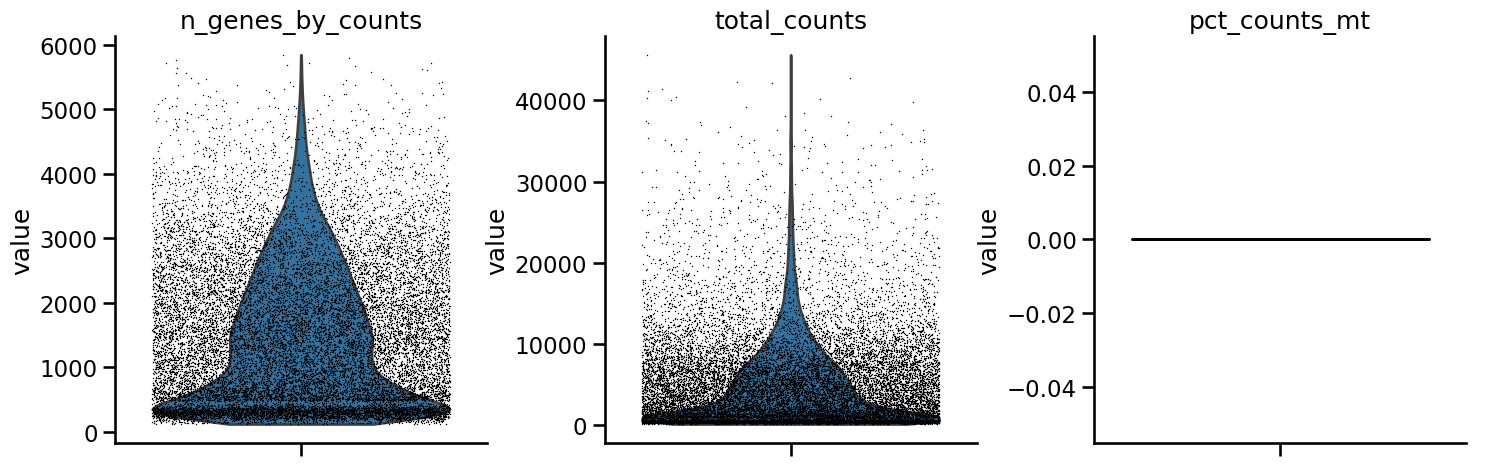

(21543, 19261)


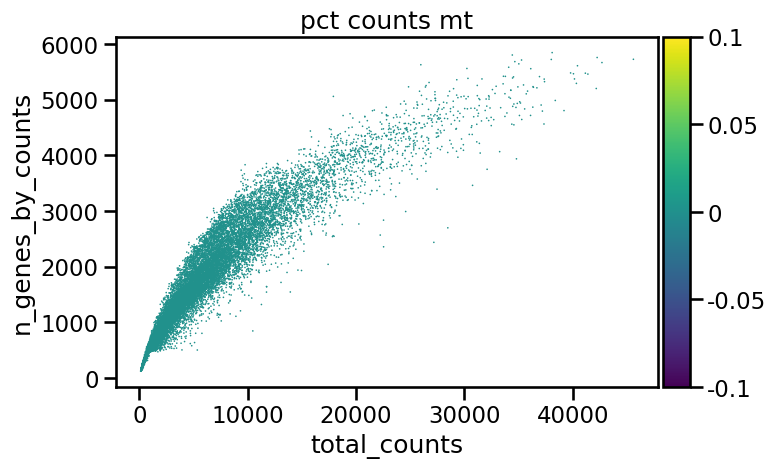

(21543, 17165)


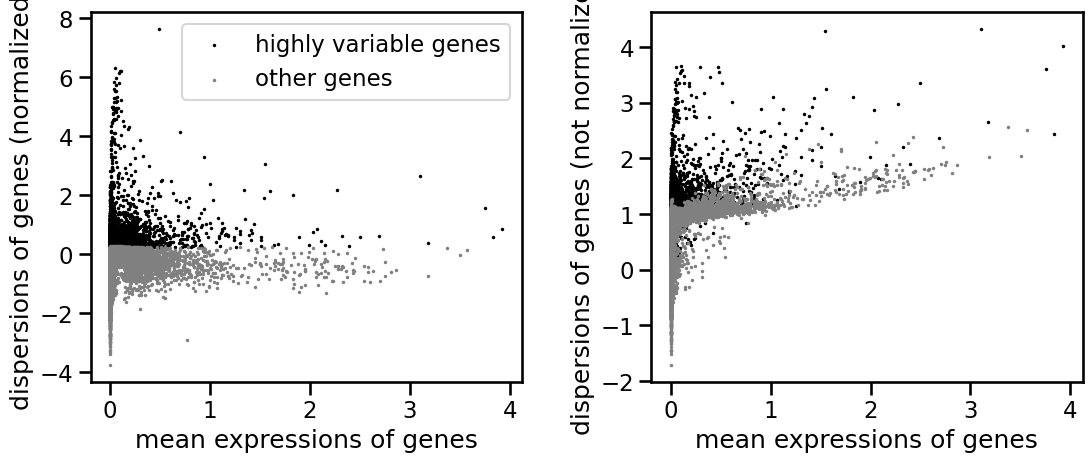

In [5]:
import scanpy as sc
from scib.integration import combat

import scanpy as sc
adata.layers["counts"] = adata.X.copy()
raw_var_names = adata.var_names.copy()

rawadata = adata.copy()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


print(adata.X.shape)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(adata.X.shape)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=5000,batch_key="type")
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']]

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


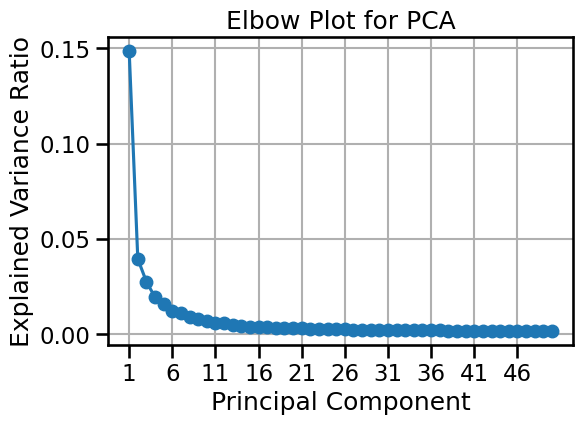

In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

sc.tl.pca(adata, n_comps=46)

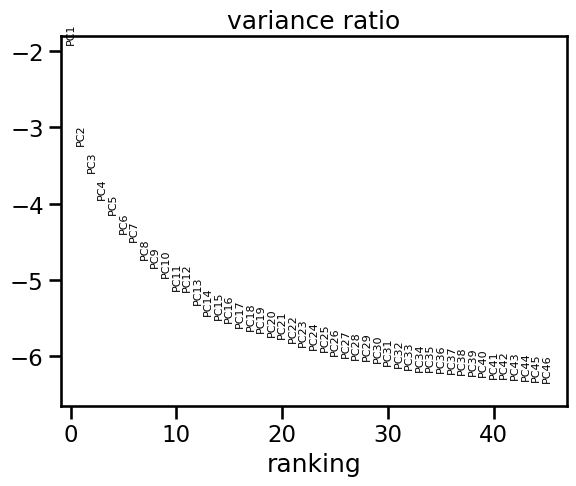

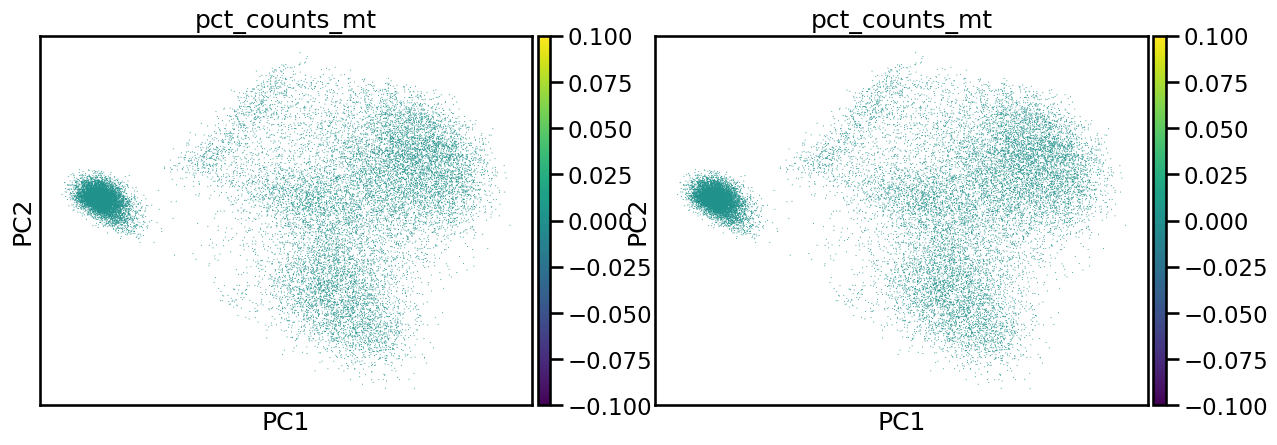

In [7]:
sc.pl.pca_variance_ratio(adata, n_pcs=46, log=True)
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    ncols=2,
    size=2,
)

In [8]:
trainadata = adata[adata.obs['type'] == 'train_data'].copy()
predictadata = adata[adata.obs['type'] == 'predict_data'].copy()

In [15]:
trainadata.obs['cell_type'].value_counts()

cell_type
M0    4145
M1    1904
M2    1527
Name: count, dtype: int64

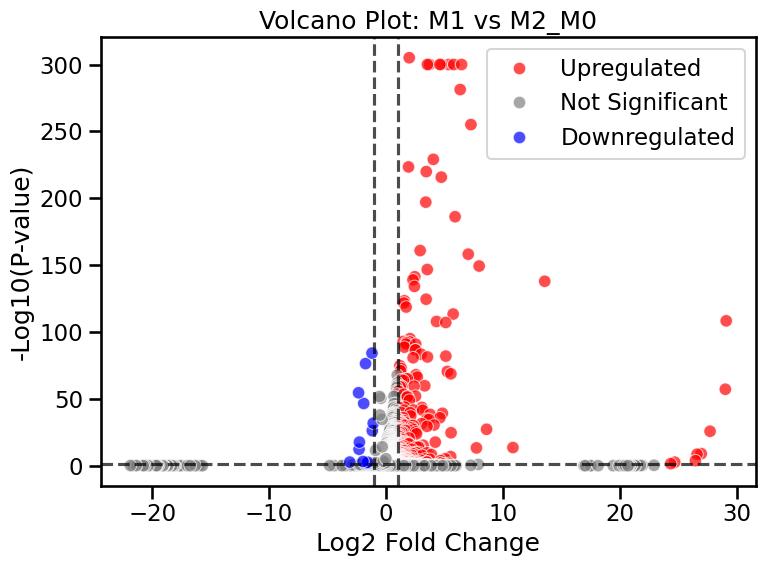

['GBP5', 'CXCL10', 'UBD', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'RSAD2', 'GBP1', 'GBP4', 'ANKRD22', 'TRIM22', 'AIM2', 'TAP1', 'IFIT2', 'IFIT3', 'PSTPIP2', 'SAMD9L', 'GBP2', 'GBP3']


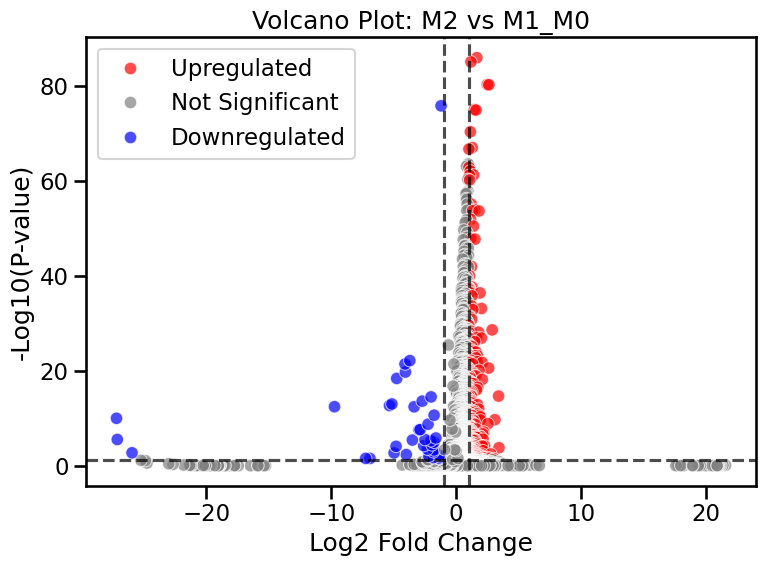

['SIGLEC10', 'CXCR4', 'CD300LB', 'TNNI2', 'SPP1', 'SLIT3', 'CXCR2', 'NET1', 'OLR1', 'PSD3', 'RGS16', 'INAVA', 'FBP1', 'FYN', 'RHOU', 'ALOX15', 'PLAU', 'LPL', 'GPR183', 'MFGE8']


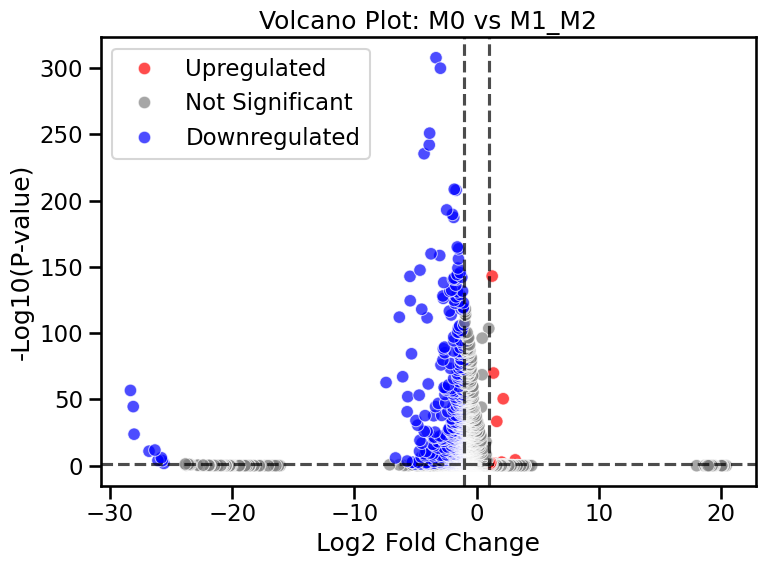

['ABCA1', 'TEX30', 'SERPINI1', 'MRPS6', 'SLC5A3', 'SUCNR1', 'TIMP1', 'CYTIP', 'PLPP1', 'SCD']


In [34]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 특정 그룹을 묶어서 새로운 참조 그룹 생성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# 🔹 그룹 병합 함수
def merge_groups(adata, groupby, group1, ref_groups):
    adata = adata.copy()
    ref_name = "_".join(ref_groups)  # 예: "M2_M3"
    adata.obs[groupby] = adata.obs[groupby].astype(str)
    
    # ref_groups를 하나의 그룹으로 묶기
    adata.obs[groupby] = adata.obs[groupby].replace(ref_groups, ref_name)
    
    return adata, ref_name

# 🔹 볼케이노 플롯 함수
def plot_volcano(deg_results, group1, reference):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=deg_results, x="logFC", y="neg_log_pval", hue="significance",
                    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "gray"},
                    alpha=0.7)

    plt.axvline(x=1, linestyle='--', color='black', alpha=0.7)
    plt.axvline(x=-1, linestyle='--', color='black', alpha=0.7)
    plt.axhline(y=-np.log10(0.05), linestyle='--', color='black', alpha=0.7)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10(P-value)")
    plt.title(f"Volcano Plot: {group1} vs {reference}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 🔹 DEG 분석 함수 + Upregulated 유전자 반환 (log2FC ≤ 5)
def run_deg_analysis(adata, groupby, group1, ref_groups, logfc_threshold=1, pval_threshold=0.05, top_n=20):
    # 그룹 병합
    adata, reference = merge_groups(adata, groupby, group1, ref_groups)
    
    # DEG 분석 (Wilcoxon rank-sum test)
    sc.tl.rank_genes_groups(adata, groupby=groupby, groups=[group1], reference=reference, method='wilcoxon')

    # 결과 저장
    result = adata.uns['rank_genes_groups']
    deg_results = pd.DataFrame({
        "gene": result['names'][group1],
        "logFC": result['logfoldchanges'][group1],
        "pval": result['pvals'][group1]
    })

    # 0을 작은 값으로 대체하여 log 변환 가능하게 처리
    deg_results["pval"] = deg_results["pval"].replace(0, 1e-300)
    deg_results["neg_log_pval"] = -np.log10(deg_results["pval"])

    # DEG 필터링 및 라벨링
    deg_results["significance"] = "Not Significant"
    deg_results.loc[(deg_results["logFC"] > logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Upregulated"
    deg_results.loc[(deg_results["logFC"] < -logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Downregulated"

    # 볼케이노 플롯
    plot_volcano(deg_results, group1, reference)

    # 🔹 log2FC ≤ 5 조건 추가 후 상위 20개 Upregulated 유전자 추출
    upregulated_genes = deg_results[
        (deg_results["logFC"] > logfc_threshold) & 
        (deg_results["logFC"] <= 10000) & 
        (deg_results["pval"] < pval_threshold)
    ].sort_values("logFC", ascending=False)["gene"].head(top_n).tolist()

    return upregulated_genes


upregulated_gene_list = run_deg_analysis(trainadata, groupby="cell_type", group1="M1", ref_groups=["M2","M0"])
print(upregulated_gene_list)
upregulated_gene_list = run_deg_analysis(trainadata, groupby="cell_type", group1="M2", ref_groups=["M1","M0"])
print(upregulated_gene_list)
upregulated_gene_list = run_deg_analysis(trainadata, groupby="cell_type", group1="M0", ref_groups=["M1", "M2"])
print(upregulated_gene_list)

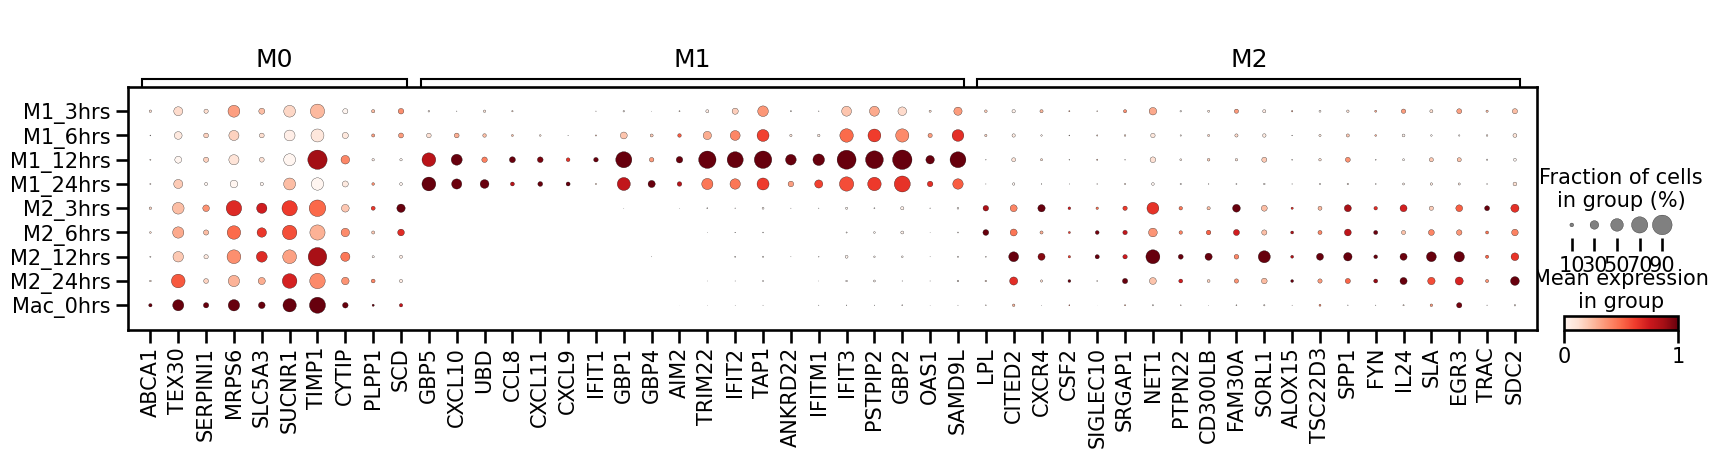

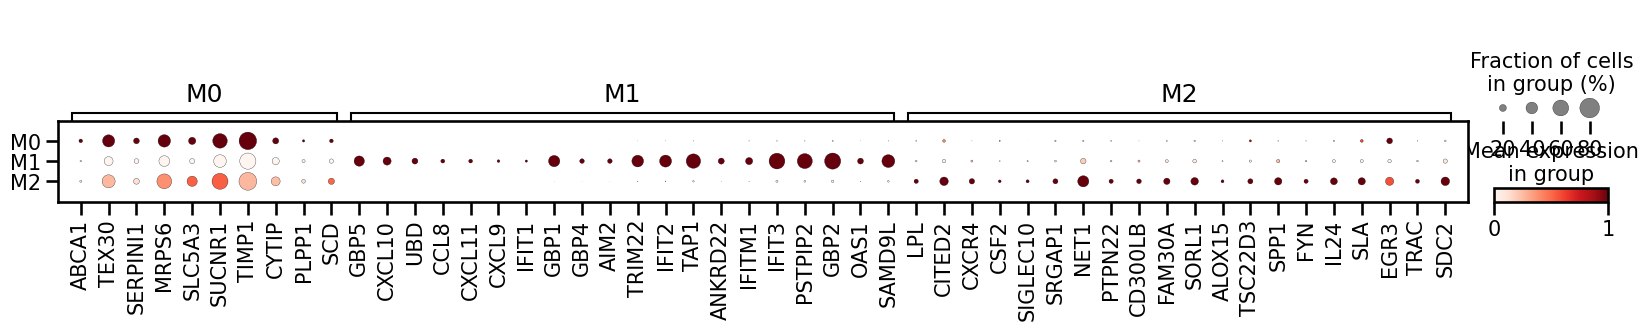

In [18]:
marker_genes = {
    "M0": ['ABCA1', 'TEX30', 'SERPINI1', 'MRPS6', 'SLC5A3', 'SUCNR1', 'TIMP1', 'CYTIP', 'PLPP1', 'SCD'],
    "M1": ['GBP5', 'CXCL10', 'UBD', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'GBP1', 'GBP4', 'AIM2', 'TRIM22', 'IFIT2', 'TAP1', 'ANKRD22', 'IFITM1', 'IFIT3', 'PSTPIP2', 'GBP2', 'OAS1', 'SAMD9L'],
    "M2": ['LPL', 'CITED2', 'CXCR4', 'CSF2', 'SIGLEC10', 'SRGAP1', 'NET1', 'PTPN22', 'CD300LB', 'FAM30A', 'SORL1', 'ALOX15', 'TSC22D3', 'SPP1', 'FYN', 'IL24', 'SLA', 'EGR3', 'TRAC', 'SDC2']
}
marker_genes = {cat: [gene for gene in genes if gene in adata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(trainadata, marker_genes, groupby="sample", standard_scale="var")
sc.pl.dotplot(trainadata, marker_genes, groupby="cell_type", standard_scale="var")

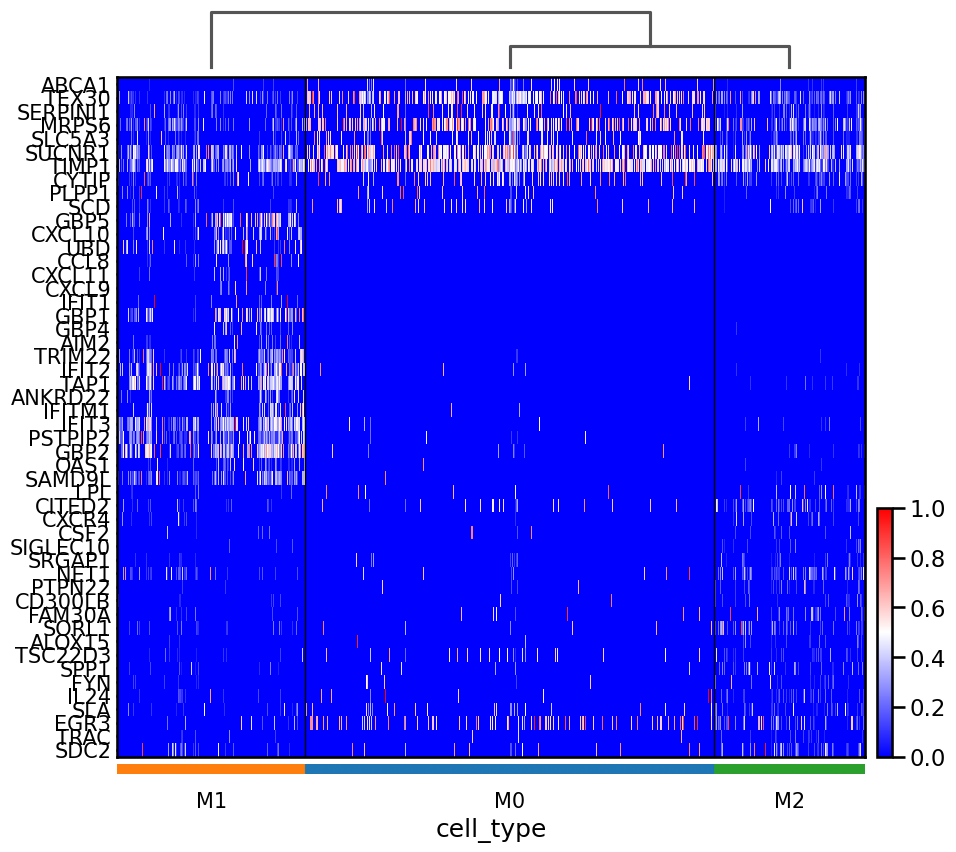

In [19]:
import scanpy as sc

# marker genes를 평탄화해서 하나의 리스트로 만들기
marker_gene_list = marker_genes["M0"] + marker_genes["M1"] + marker_genes["M2"]

# 히트맵 그리기
sc.pl.heatmap(
    trainadata,
    var_names=marker_gene_list,
    groupby='cell_type',       # cell type 별 평균 발현 보여줌
    use_raw=False,             # 필요한 경우 True로 (adata.raw에 데이터가 있을 경우)
    cmap='bwr',                # blue-white-red 색상
    swap_axes=True,            # 유전자가 x축
    dendrogram=True,           # 클러스터링
    standard_scale='var'       # 유전자별 z-score 정규화 (선택)
)


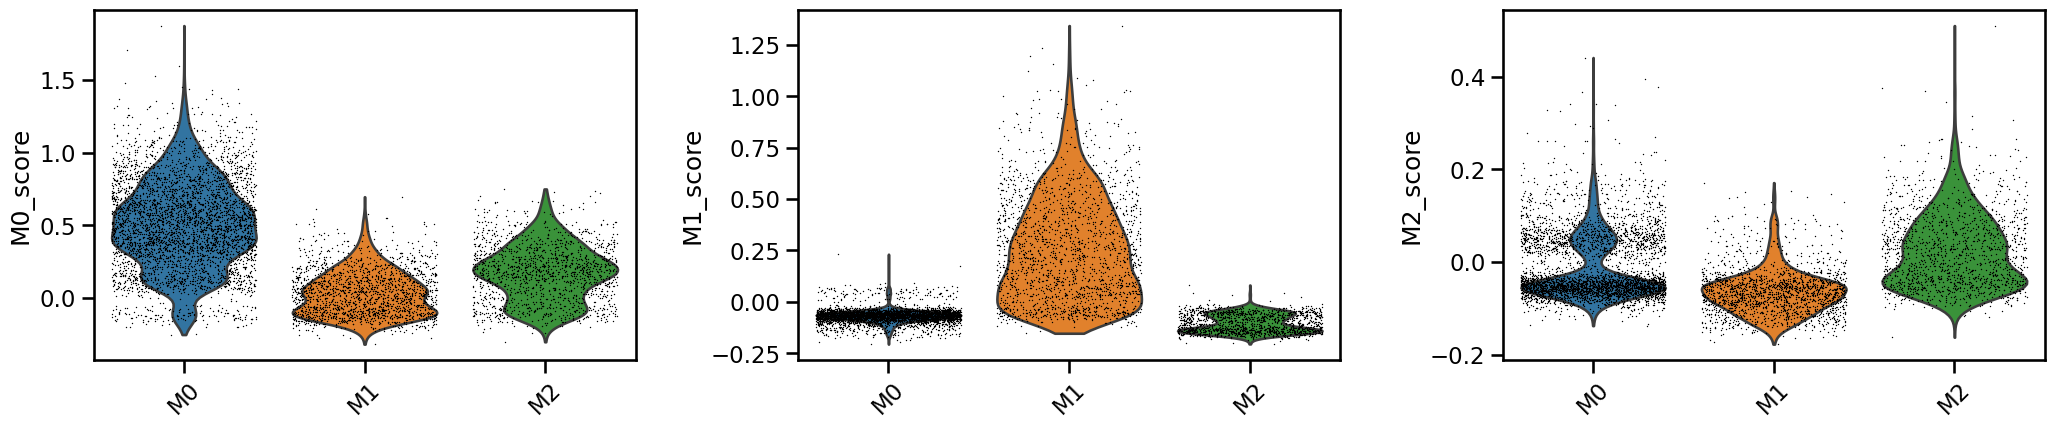

In [20]:
# 각 마커에 대해 score 계산
for label, genes in marker_genes.items():
    sc.tl.score_genes(trainadata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(trainadata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='cell_type', jitter=0.4, rotation=45)


In [21]:
all_genes = marker_genes["M0"] + marker_genes["M1"] + marker_genes["M2"]

# 실제 adata.var_names에 존재하는 유전자만 필터링
existing_genes = [gene for gene in all_genes if gene in trainadata.var_names]

# 유전자 발현값 추출
gene_df = trainadata[:, existing_genes].to_df()

# cell_type 열 추가
gene_df['cell_type'] = trainadata.obs['cell_type'].values

# 결과 확인 (옵션)
gene_df


,ABCA1,TEX30,SERPINI1,MRPS6,SLC5A3,SUCNR1,TIMP1,CYTIP,PLPP1,SCD,...,ALOX15,TSC22D3,SPP1,FYN,IL24,SLA,EGR3,TRAC,SDC2,cell_type
Mac_0hrs_BM0_cell10002-0,0.000000,1.300919,0.00000,0.782921,0.466200,1.450816,1.799790,0.466200,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.260026,0.260026,0.000000,0.0,0.000000,M0
Mac_0hrs_BM0_cell10004-0,0.277413,0.494344,0.00000,1.756559,1.508516,1.070990,1.070990,0.954956,0.000000,1.507809,...,0.0,0.277413,1.576198,0.000000,0.000000,0.000000,0.000000,0.0,0.672502,M0
Mac_0hrs_BM0_cell10006-0,0.000000,1.263167,0.00000,0.309227,0.309227,1.742365,1.033846,0.735783,0.000000,0.309227,...,0.0,0.000000,0.000000,0.895879,0.000000,0.000000,0.545079,0.0,0.000000,M0
Mac_0hrs_BM0_cell10007-0,0.864548,1.436475,0.37705,1.436475,1.633506,1.040952,2.658955,1.190854,0.650216,0.650216,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.377050,0.0,0.000000,M0
Mac_0hrs_BM0_cell10008-0,0.984443,0.984443,0.00000,0.850602,0.984443,2.125347,2.372359,1.208019,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.289129,0.696039,0.0,0.000000,M0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M2_24hrs_LM2.24hrs_celll489-8,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.644013,2.644013,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,M2
M2_24hrs_LM2.24hrs_celll493-8,0.000000,2.088527,0.00000,0.000000,0.000000,2.717739,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,M2
M2_24hrs_LM2.24hrs_celll494-8,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,M2
M2_24hrs_LM2.24hrs_celll495-8,2.474926,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,M2


📊 Confusion Matrix:
[[747  17  65]
 [ 25 320  36]
 [ 47  11 248]]

📝 Classification Report:
              precision    recall  f1-score   support

          M0       0.91      0.90      0.91       829
          M1       0.92      0.84      0.88       381
          M2       0.71      0.81      0.76       306

    accuracy                           0.87      1516
   macro avg       0.85      0.85      0.85      1516
weighted avg       0.87      0.87      0.87      1516



/tmp/ipykernel_744434/4171257650.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


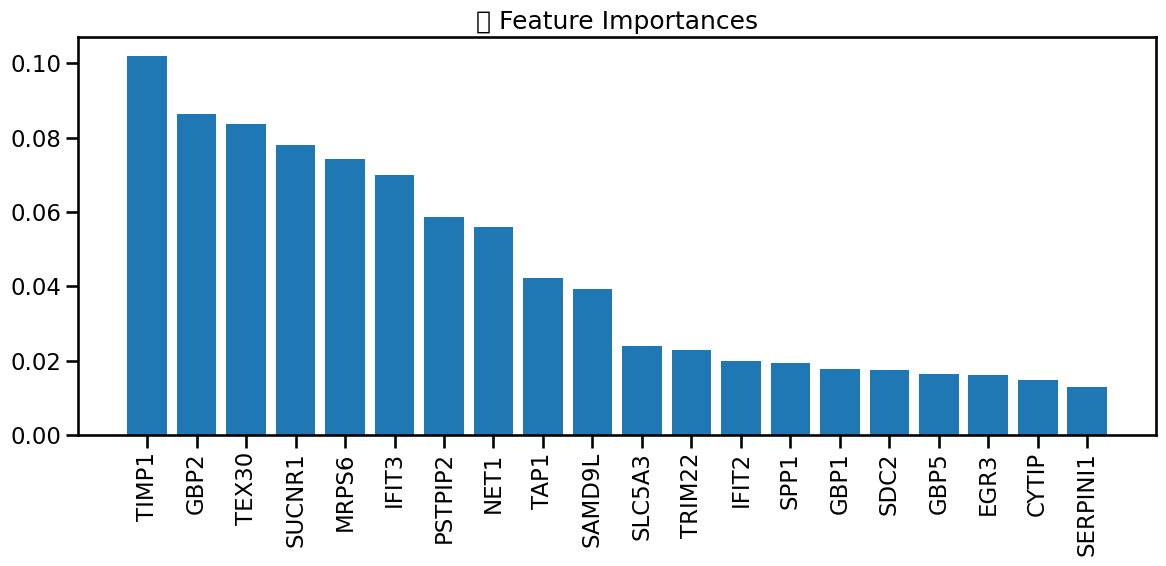


✅ Cross-Validation Accuracy Scores: [0.80738786 0.90363036 0.88580858 0.90891089 0.82442244]
📌 Mean CV Accuracy: 0.8660


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature와 Label 분리
X = gene_df.drop(columns='cell_type')
y = gene_df['cell_type']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = X_train
X_test_scaled = X_test


# 4. 기본 RandomForest 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 5. 예측 및 평가
y_pred = rf.predict(X_test_scaled)

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Feature Importance 시각화
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]

plt.figure(figsize=(12, 6))
plt.title("📈 Feature Importances")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), features[:20], rotation=90)
plt.tight_layout()
plt.show()

# 7. Cross-validation score (기본 모델 성능 확인)
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\n✅ Cross-Validation Accuracy Scores: {cv_scores}")
print(f"📌 Mean CV Accuracy: {cv_scores.mean():.4f}")

In [23]:
# 8. GridSearchCV로 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n🔍 Best Parameters: {grid_search.best_params_}")
print(f"🎯 Best CV Score: {grid_search.best_score_:.4f}")

# 최적 모델로 테스트셋 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\n🧪 Test Set Evaluation (Best Model):")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 24 candidates, totalling 72 fits

🔍 Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
🎯 Best CV Score: 0.8947

🧪 Test Set Evaluation (Best Model):
[[771   7  51]
 [ 21 318  42]
 [ 51   7 248]]
              precision    recall  f1-score   support

          M0       0.91      0.93      0.92       829
          M1       0.96      0.83      0.89       381
          M2       0.73      0.81      0.77       306

    accuracy                           0.88      1516
   macro avg       0.87      0.86      0.86      1516
weighted avg       0.89      0.88      0.88      1516



In [24]:
test_df = predictadata[:, existing_genes].to_df()
test_scaled_df = pd.DataFrame(test_df, columns=existing_genes, index=test_df.index)

test_scaled_df

,ABCA1,TEX30,SERPINI1,MRPS6,SLC5A3,SUCNR1,TIMP1,CYTIP,PLPP1,SCD,...,SORL1,ALOX15,TSC22D3,SPP1,FYN,IL24,SLA,EGR3,TRAC,SDC2
AAAGATGTCAATACCG_8,0.000000,0.0,0.0,0.509942,0.287130,0.0,0.000000,0.287130,0.00000,0.287130,...,0.000000,0.0,1.097139,0.000000,0.0,0.0,0.287130,0.692043,0.0,0.287130
AACTCTTGTAAGGGCT_8,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.64281,0.000000,...,0.000000,0.0,1.642810,0.000000,0.0,0.0,1.642810,0.000000,0.0,0.000000
AAGGCAGTCAAACGGG_8,0.000000,0.0,0.0,1.586519,0.000000,0.0,0.000000,1.079550,0.00000,0.000000,...,0.000000,0.0,1.586519,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
AATCCAGCACCGATAT_8,1.061970,0.0,0.0,0.274098,0.000000,0.0,0.815973,0.274098,0.00000,0.000000,...,0.000000,0.0,0.815973,0.000000,0.0,0.0,1.061970,0.000000,0.0,0.489002
ACAGCTATCGAGAGCA_8,0.000000,0.0,0.0,0.000000,0.000000,0.0,2.743762,0.220365,0.00000,0.000000,...,0.000000,0.0,0.553652,0.000000,0.0,0.0,0.000000,0.220365,0.0,0.220365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGTCAGCTGAAAT.1_40,0.000000,0.0,0.0,0.000000,0.659137,0.0,0.000000,1.053004,0.00000,0.000000,...,0.000000,0.0,1.554453,0.000000,0.0,0.0,0.270822,0.938133,0.0,0.000000
TTTAGTCGTCTGGTTA.1_40,1.597061,0.0,0.0,0.362982,0.362982,0.0,1.288037,0.362982,0.00000,1.504274,...,0.000000,0.0,0.838473,0.362982,0.0,0.0,0.362982,0.628727,0.0,0.628727
TTTCACATCATTGCGA.1_40,0.807340,0.0,0.0,0.000000,0.000000,0.0,3.150804,0.000000,0.00000,0.000000,...,0.483023,0.0,1.676493,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
TTTGGTTGTGAGCTCC.1_40,0.549152,0.0,0.0,0.000000,0.549152,0.0,0.901611,0.000000,0.00000,0.000000,...,0.000000,0.0,1.538784,0.000000,0.0,0.0,0.549152,1.161698,0.0,0.000000


In [25]:
# 예측 확률 추출
test_proba = rf.predict_proba(test_scaled_df.values)
test_pred = rf.predict(test_scaled_df.values)
# 클래스 라벨
class_labels = rf.classes_

# 확률 DataFrame 생성
proba_df = pd.DataFrame(test_proba, columns=[f'proba_{cls}' for cls in class_labels], index=test_scaled_df.index)

# cell_id와 predicted_cell_type 포함한 기본 DataFrame
test_pred_df = pd.DataFrame({
    'cell_id': test_scaled_df.index,
    'predicted_cell_type': test_pred
})

# 확률 정보 붙이기
test_pred_df = pd.concat([test_pred_df, proba_df.reset_index(drop=True)], axis=1)

# 결과 확인
print(test_pred_df.head())


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


              cell_id predicted_cell_type  proba_M0  proba_M1  proba_M2
0  AAAGATGTCAATACCG_8                  M1      0.05      0.61      0.34
1  AACTCTTGTAAGGGCT_8                  M2      0.32      0.12      0.56
2  AAGGCAGTCAAACGGG_8                  M2      0.09      0.37      0.54
3  AATCCAGCACCGATAT_8                  M2      0.34      0.20      0.46
4  ACAGCTATCGAGAGCA_8                  M2      0.22      0.27      0.51


In [26]:
test_pred_df['predicted_cell_type'].value_counts()

predicted_cell_type
M2    6532
M1    5668
M0    1767
Name: count, dtype: int64

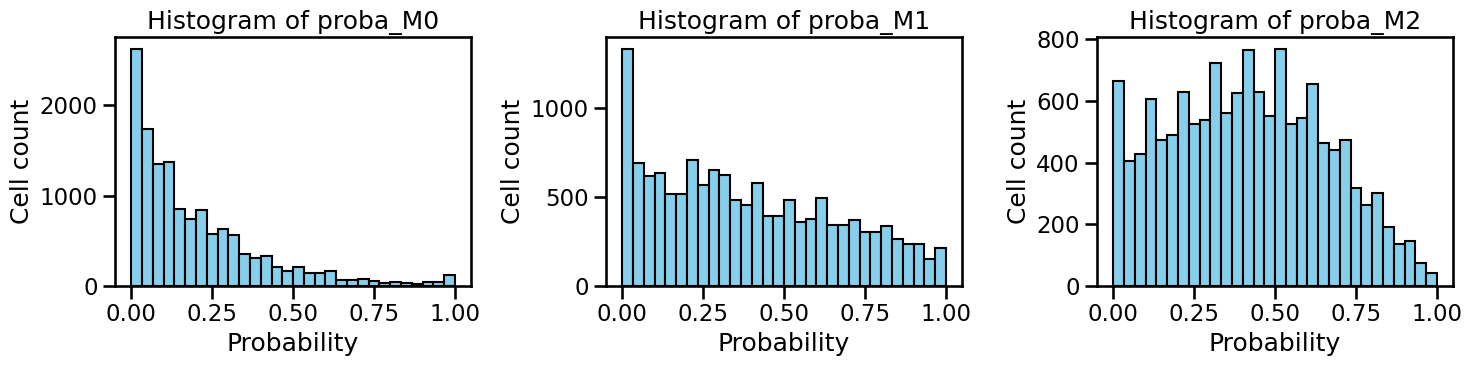

In [27]:
import matplotlib.pyplot as plt
proba_cols = ['proba_M0', 'proba_M1', 'proba_M2']

proba = rf.predict_proba(test_scaled_df)
predictadata.obs['predict'] = test_pred
# 다중 클래스라면, 결과가 list of arrays일 수 있음 (클래스별)
# 각 클래스 확률을 obs에 저장
for i, class_name in enumerate(['proba_M0', 'proba_M1', 'proba_M2']):
    predictadata.obs[class_name] = proba[:, i]

# 플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(proba_cols):
    axes[i].hist(predictadata.obs[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('Probability')
    axes[i].set_ylabel('Cell count')




plt.tight_layout()
plt.show()
# print(predictadata.obs.groupby('status')['predict'].value_counts())

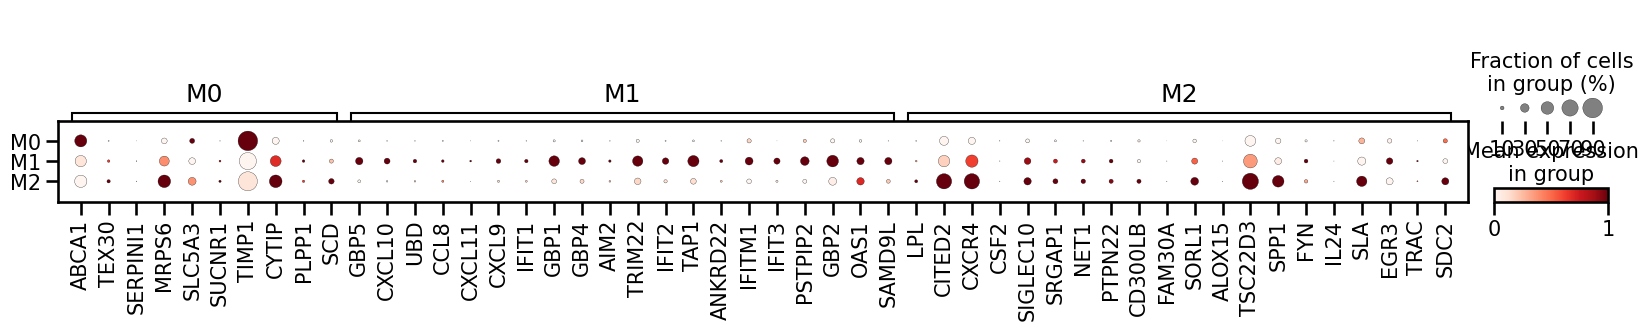

In [28]:
marker_genes = {cat: [gene for gene in genes if gene in predictadata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(predictadata, marker_genes, groupby="predict", standard_scale="var")

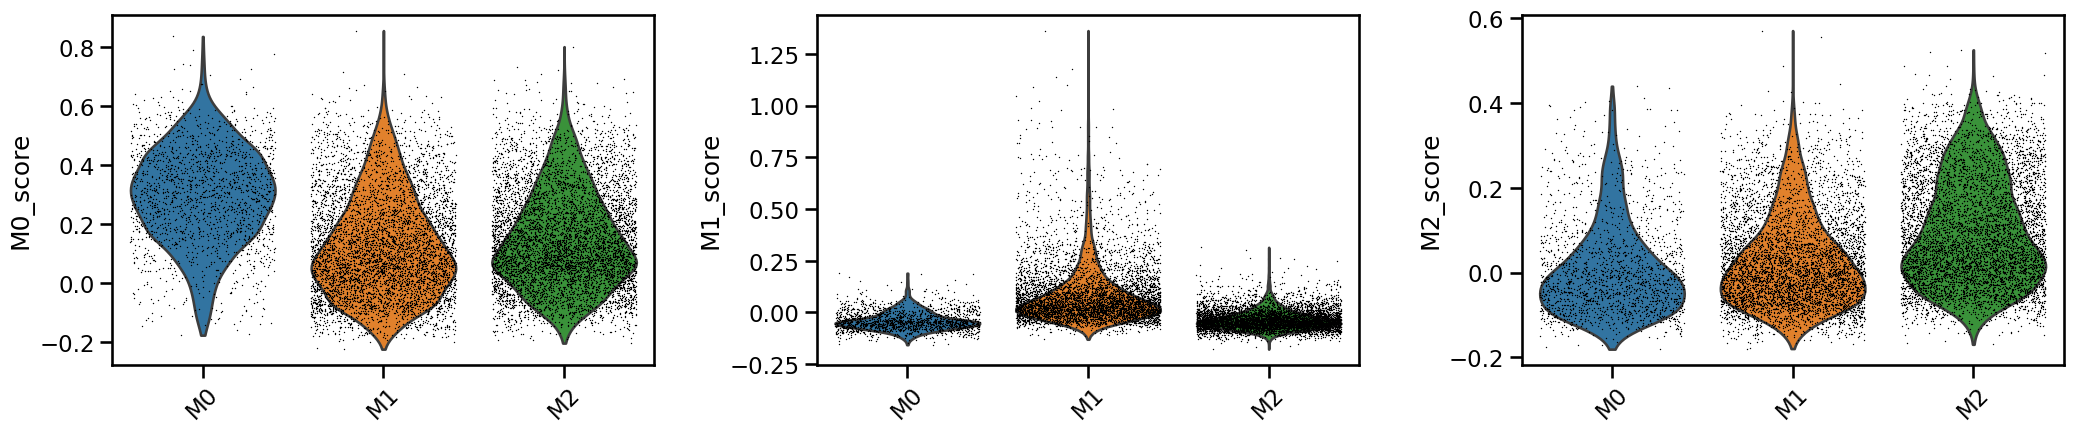

In [29]:
for label, genes in marker_genes.items():
    sc.tl.score_genes(predictadata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(predictadata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='predict', jitter=0.4, rotation=45)

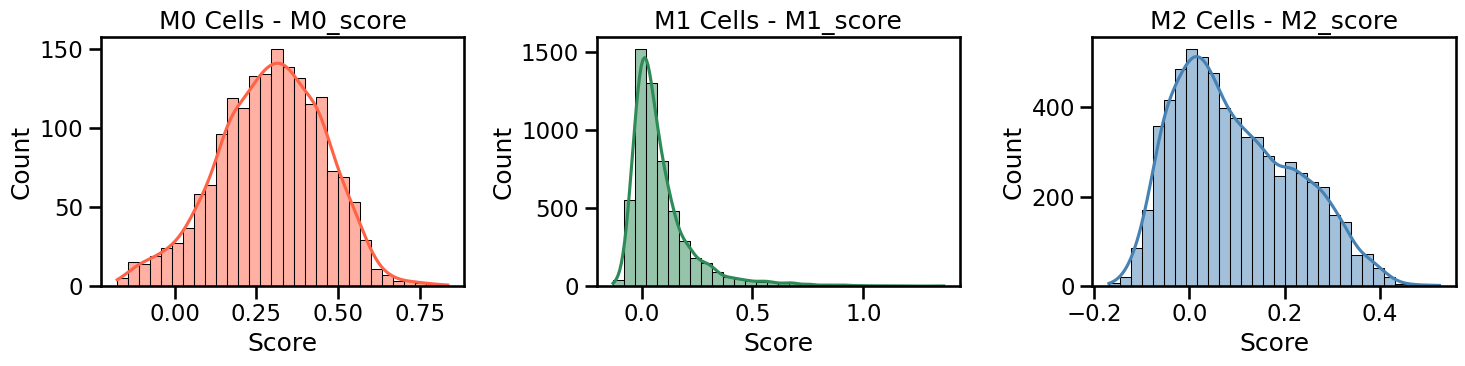

In [30]:
# 그룹별로 관련 score만 추출
df_M0 = predictadata.obs[predictadata.obs['predict'] == 'M0'][['M0_score']]
df_M1 = predictadata.obs[predictadata.obs['predict'] == 'M1'][['M1_score']]
df_M2 = predictadata.obs[predictadata.obs['predict'] == 'M2'][['M2_score']]
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# M0
sns.histplot(df_M0['M0_score'], bins=30, kde=True, ax=axs[0], color='tomato')
axs[0].set_title('M0 Cells - M0_score')

# M1
sns.histplot(df_M1['M1_score'], bins=30, kde=True, ax=axs[1], color='seagreen')
axs[1].set_title('M1 Cells - M1_score')

# M2
sns.histplot(df_M2['M2_score'], bins=30, kde=True, ax=axs[2], color='steelblue')
axs[2].set_title('M2 Cells - M2_score')

for ax in axs:
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [31]:
# 1. final 값을 복사해서 final_celltype 생성
predictadata.obs['final_celltype'] = predictadata.obs['predict'].copy()

# 2. Categorical이면 'Unknown'이 없을 때만 추가
if pd.api.types.is_categorical_dtype(predictadata.obs['final_celltype']):
    if 'Unknown' not in predictadata.obs['final_celltype'].cat.categories:
        predictadata.obs['final_celltype'] = predictadata.obs['final_celltype'].cat.add_categories(['Unknown'])

# 3. 조건별로 Unknown으로 변경
predictadata.obs.loc[(predictadata.obs['predict'] == 'M0') & (predictadata.obs['M0_score'] < 0), 'final_celltype'] = 'Unknown'
predictadata.obs.loc[(predictadata.obs['predict'] == 'M1') & (predictadata.obs['M1_score'] < 0), 'final_celltype'] = 'Unknown'
predictadata.obs.loc[(predictadata.obs['predict'] == 'M2') & (predictadata.obs['M2_score'] < 0), 'final_celltype'] = 'Unknown'
predictadata.obs['final_celltype'].value_counts()

/tmp/ipykernel_744434/2842248453.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(predictadata.obs['final_celltype']):


final_celltype
M2         4838
M1         4241
Unknown    3204
M0         1684
Name: count, dtype: int64

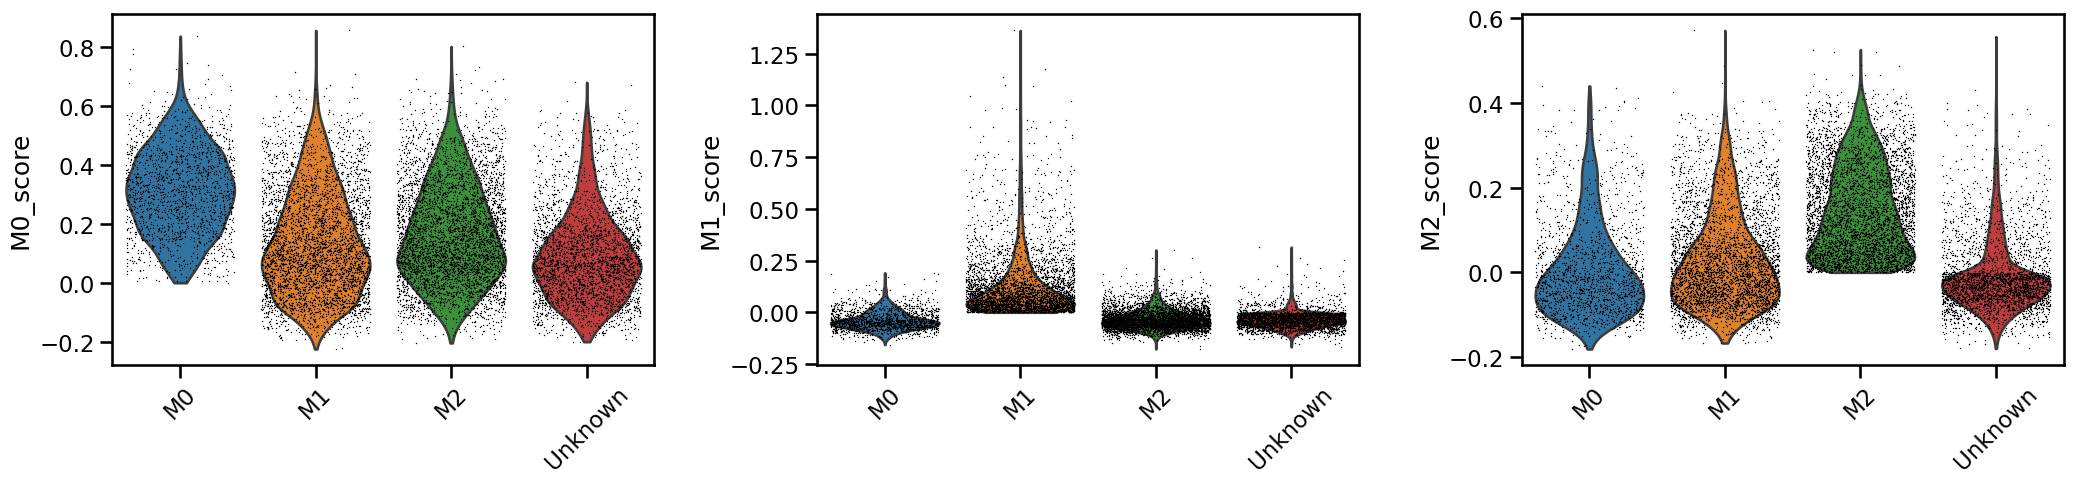

In [32]:
sc.pl.violin(predictadata, keys=['M0_score', 'M1_score', 'M2_score'], groupby='final_celltype', jitter=0.4, rotation=45)

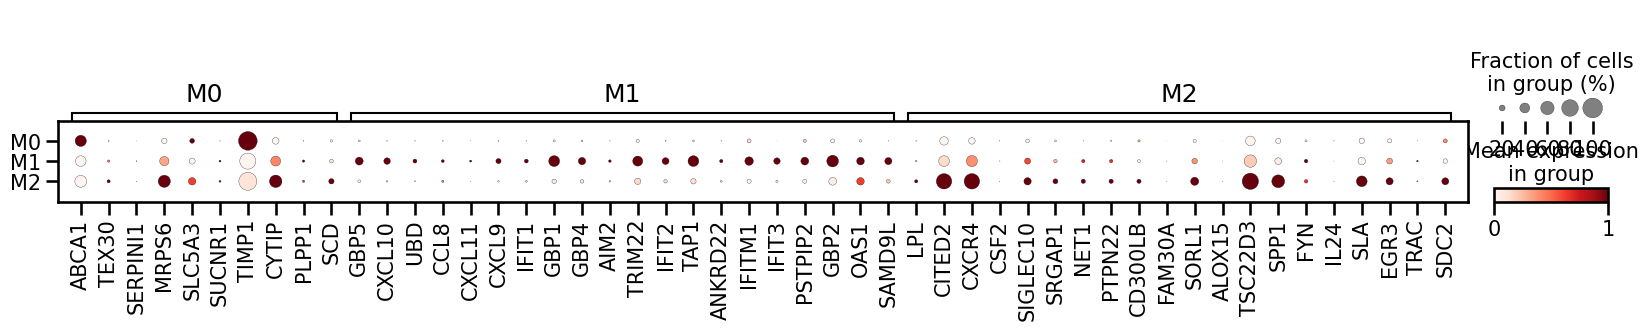

In [33]:
predictadata = predictadata[predictadata.obs['final_celltype'] != 'Unknown']
sc.pl.dotplot(predictadata, marker_genes, groupby="final_celltype", standard_scale="var")

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


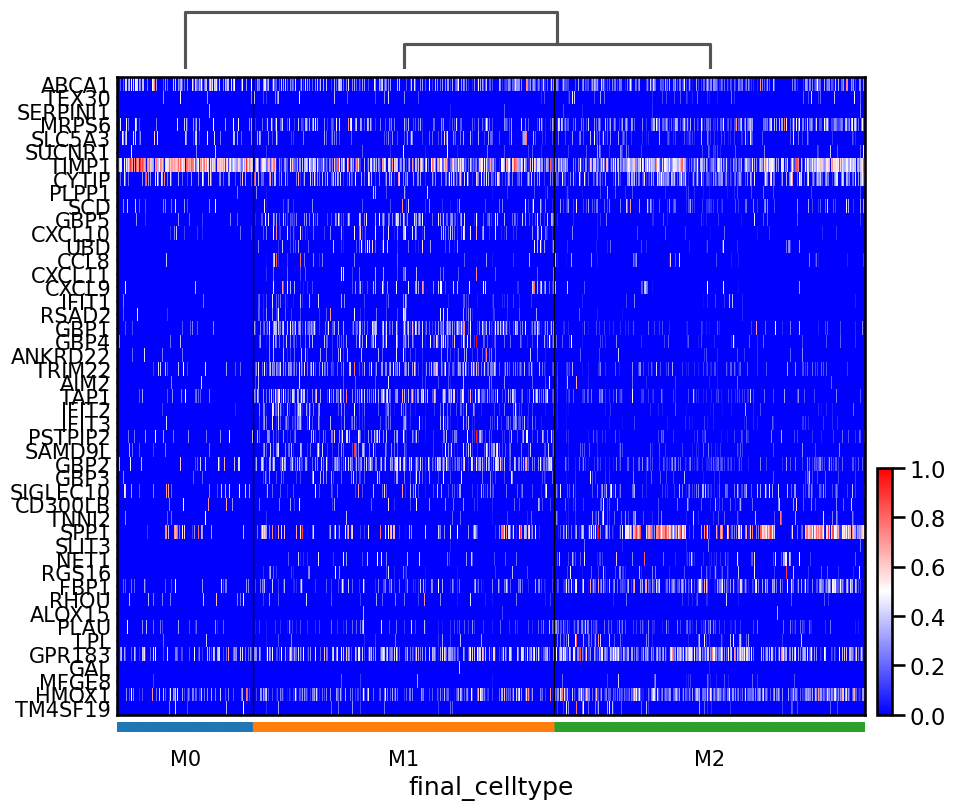

In [26]:
sc.pl.heatmap(
    predictadata,
    var_names=marker_gene_list,
    groupby='final_celltype',       # cell type 별 평균 발현 보여줌
    use_raw=False,             # 필요한 경우 True로 (adata.raw에 데이터가 있을 경우)
    cmap='bwr',                # blue-white-red 색상
    swap_axes=True,            # 유전자가 x축
    dendrogram=True,           # 클러스터링
    standard_scale='var'       # 유전자별 z-score 정규화 (선택)
)


/tmp/ipykernel_56833/3742732707.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  top_genes_unique = list(pd.unique(top_genes_per_cluster))


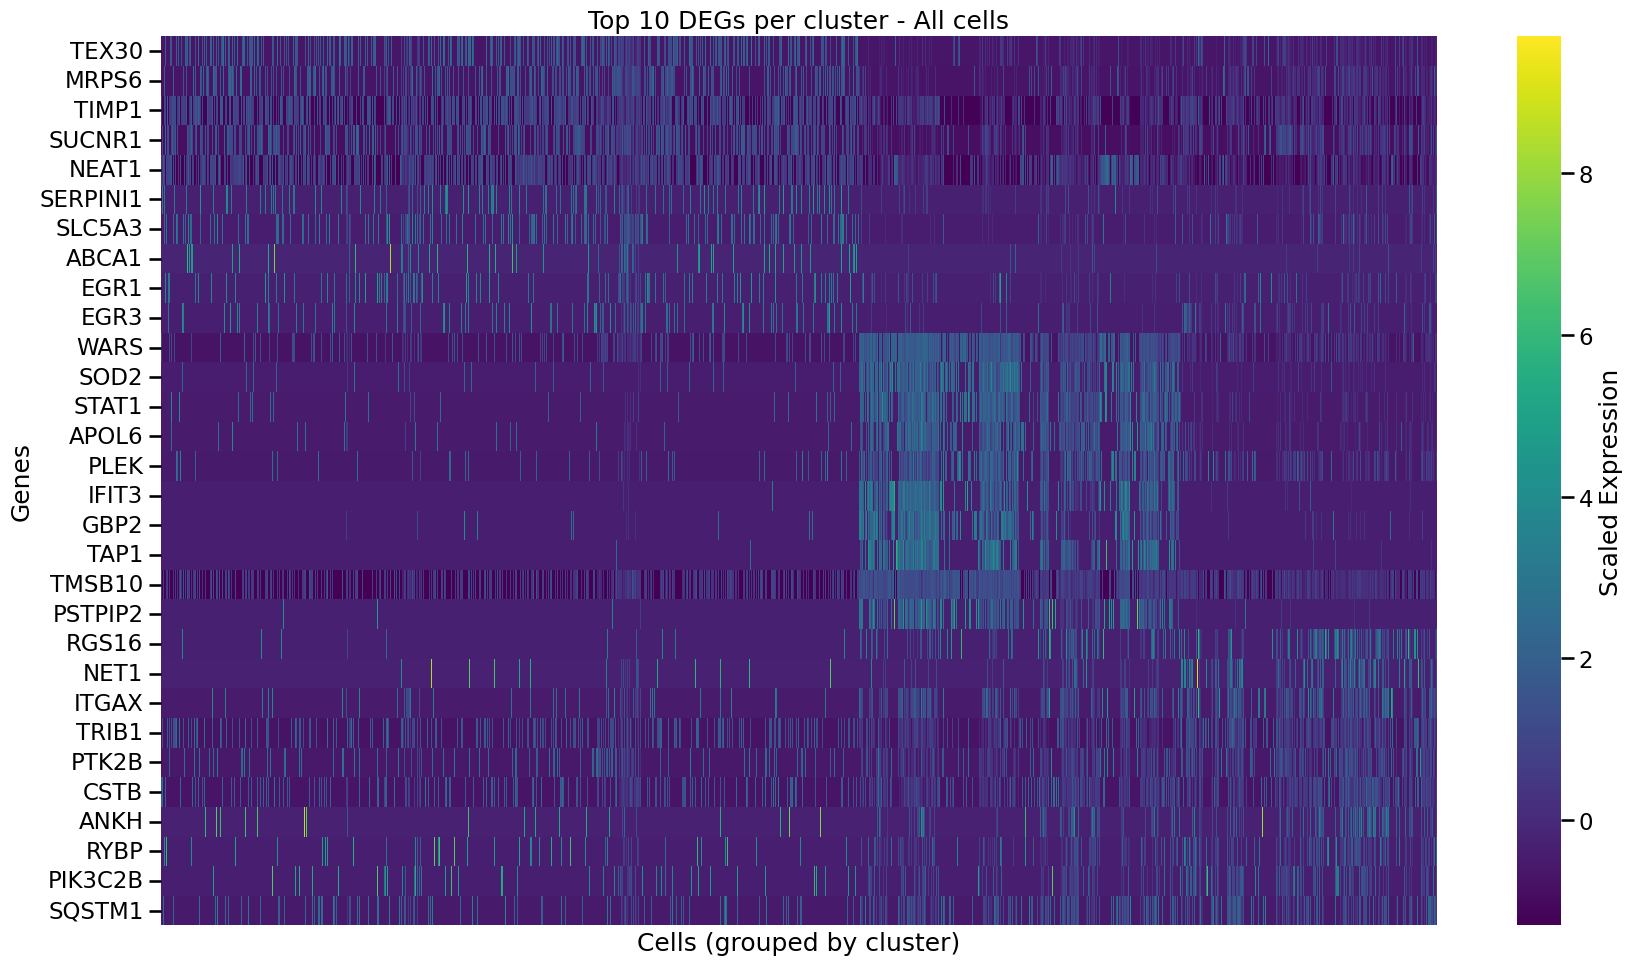

In [27]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DEG 계산 (이미 수행했으면 생략 가능)
sc.tl.rank_genes_groups(trainadata, groupby='cell_type', method='t-test')

# 클러스터별 top 10 gene 추출
top_genes_per_cluster = []
for cluster in trainadata.obs['cell_type'].cat.categories:
    top_genes = trainadata.uns['rank_genes_groups']['names'][cluster][:10]
    top_genes_per_cluster.extend(top_genes)

# 중복 제거
top_genes_unique = list(pd.unique(top_genes_per_cluster))

# scale data (선택사항)
sc.pp.scale(trainadata, max_value=10)

# 유전자 발현 데이터 추출
data_matrix = trainadata[:, top_genes_unique].X
data_df = pd.DataFrame(data_matrix.toarray(), columns=top_genes_unique, index=trainadata.obs_names)

# 클러스터 정보 추가
data_df['cluster'] = trainadata.obs['cell_type'].values

# 세포별로 정렬 (선택)
data_df_sorted = data_df.sort_values('cluster')
cluster_labels = data_df_sorted['cluster']
data_df_sorted = data_df_sorted.drop(columns='cluster')

# heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(data_df_sorted.T, cmap='viridis', yticklabels=True, xticklabels=False,
            cbar_kws={'label': 'Scaled Expression'})

plt.title('Top 10 DEGs per cluster - All cells')
plt.xlabel('Cells (grouped by cluster)')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()


In [28]:
predictadata.X = predictadata.layers['counts']

In [29]:
predictadata.write("/home/Data_Drive_8TB/kykim/GC/predict.h5ad")